In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')   

# Lecture des fichiers — on utilise .squeeze() sur y pour passer
# de DataFrame (1 colonne) à Series (plus pratique pour sklearn).
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Vérification rapide que les dimensions et la stratification sont OK
print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}  | y_test  : {y_test.shape}")
print(f"Taux de churn train : {y_train.mean()*100:.1f}%")
print(f"Taux de churn test  : {y_test.mean()*100:.1f}%")
# → on s'attend à ~10.2% sur les deux (stratify a bien fait son boulot)


X_train : (8000, 38) | y_train : (8000,)
X_test  : (2000, 38)  | y_test  : (2000,)
Taux de churn train : 10.2%
Taux de churn test  : 10.2%


In [15]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)

def evaluate_model(name, model, X_test, y_test, results_dict):
    """
    Évalue un modèle sur le test set, affiche les métriques principales,
    stocke le résultat dans results_dict (modifié en place pour comparaison
    finale), et retourne y_pred + y_proba pour des analyses ultérieures.

    Note : dans un projet de churn déséquilibré, le Recall et le F1-Score
    sont plus parlants que l'Accuracy (qui est trompeuse à 90% par défaut
    si on prédit tout en non-churn).
    """
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]   # probabilité de la classe positive (churn)

    metrics = {
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score'  : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_test, y_proba)
    }
    results_dict[name] = metrics

    # Affichage formaté pour repérer rapidement les forces/faiblesses
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    for k, v in metrics.items():
        print(f"  {k:<12} : {v:.4f}")
    # classification_report donne le détail par classe → utile sur dataset déséquilibré
    print(f"\n{classification_report(y_test, y_pred, target_names=['Non-Churn','Churn'])}")

    return y_pred, y_proba

# Dictionnaire qui va accumuler les résultats des 4 modèles
results = {}


In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,             # par défaut 100 → souvent insuffisant pour converger
    class_weight='balanced',   # CRUCIAL ici : pondère automatiquement les classes
                               # pour compenser le déséquilibre 90/10
    random_state=42
)
lr.fit(X_train, y_train)

# Évaluation via notre fonction utilitaire
y_pred_lr, y_proba_lr = evaluate_model('Régression Logistique', lr, X_test, y_test, results)

# On s'attend à : Recall élevé (~67%) mais Precision faible (~20%)
# → le modèle détecte beaucoup de churners mais avec beaucoup de faux positifs.
# C'est typique d'un modèle linéaire avec class_weight='balanced'.

# Sauvegarde du modèle pour le dashboard
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(lr, '../models/logistic_regression.pkl')
print("Modèle sauvegardé : models/logistic_regression.pkl")



  Régression Logistique
  Accuracy     : 0.6895
  Precision    : 0.1983
  Recall       : 0.6716
  F1-Score     : 0.3061
  ROC-AUC      : 0.7510

              precision    recall  f1-score   support

   Non-Churn       0.95      0.69      0.80      1796
       Churn       0.20      0.67      0.31       204

    accuracy                           0.69      2000
   macro avg       0.57      0.68      0.55      2000
weighted avg       0.87      0.69      0.75      2000

Modèle sauvegardé : models/logistic_regression.pkl


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,          # 100 arbres = bon compromis qualité / temps
    max_depth=10,              # plafond de profondeur → limite le surapprentissage
                               # (sans plafond, chaque arbre peut overfitter à mort)
    class_weight='balanced',   # même logique que pour la LogReg : compense le 90/10
    random_state=42,
    n_jobs=-1                  # -1 = utilise tous les cœurs CPU disponibles
)
rf.fit(X_train, y_train)

y_pred_rf, y_proba_rf = evaluate_model('Random Forest', rf, X_test, y_test, results)

# RF a tendance à mieux équilibrer Precision/Recall que la LogReg.
# Sur ce dataset on attend ~83% accuracy et un ROC-AUC autour de 0.79.

joblib.dump(rf, '../models/random_forest.pkl')
print("Modèle sauvegardé : models/random_forest.pkl")



  Random Forest
  Accuracy     : 0.8310
  Precision    : 0.2781
  Recall       : 0.4118
  F1-Score     : 0.3320
  ROC-AUC      : 0.7908

              precision    recall  f1-score   support

   Non-Churn       0.93      0.88      0.90      1796
       Churn       0.28      0.41      0.33       204

    accuracy                           0.83      2000
   macro avg       0.60      0.65      0.62      2000
weighted avg       0.86      0.83      0.84      2000

Modèle sauvegardé : models/random_forest.pkl


In [18]:
from xgboost import XGBClassifier

# XGBoost n'a pas de class_weight='balanced'. À la place, on lui passe
# scale_pos_weight = ratio non-churn / churn ≈ 8.79
# cela revient à dire "chaque erreur sur un churner pèse 8.79x plus".
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f} (ratio non-churn / churn)")

xgb = XGBClassifier(
    n_estimators=200,                    # plus d'arbres car chacun est plus "faible"
    max_depth=5,                         # arbres peu profonds : on additionne le signal
    learning_rate=0.1,                   # pas d'apprentissage standard
    scale_pos_weight=scale_pos_weight,   # compense le déséquilibre
    random_state=42,
    eval_metric='logloss',
    verbosity=0                          # mode silencieux pour ne pas polluer l'output
)
xgb.fit(X_train, y_train)

y_pred_xgb, y_proba_xgb = evaluate_model('XGBoost', xgb, X_test, y_test, results)

# XGBoost donne souvent le meilleur F1-Score sur ce type de problème
# car il sait capter les interactions complexes entre features.

joblib.dump(xgb, '../models/xgboost.pkl')
print("Modèle sauvegardé : models/xgboost.pkl")


scale_pos_weight = 8.79 (ratio non-churn / churn)

  XGBoost
  Accuracy     : 0.8160
  Precision    : 0.2657
  Recall       : 0.4559
  F1-Score     : 0.3357
  ROC-AUC      : 0.7728

              precision    recall  f1-score   support

   Non-Churn       0.93      0.86      0.89      1796
       Churn       0.27      0.46      0.34       204

    accuracy                           0.82      2000
   macro avg       0.60      0.66      0.61      2000
weighted avg       0.86      0.82      0.84      2000

Modèle sauvegardé : models/xgboost.pkl


Poids des classes : {0: np.float64(0.5568703884170959), 1: np.float64(4.8959608323133414)}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,129 (63.00 KB)

 Trainable params: 15,745 (61.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6413 - loss: 0.9042 - val_accuracy: 0.6625 - val_loss: 0.6431
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6056 - loss: 0.7255 - val_accuracy: 0.3900 - val_loss: 0.7390
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6006 - loss: 0.6754 - val_accuracy: 0.3950 - val_loss: 0.7487
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6228 - loss: 0.6640 - val_accuracy: 0.4175 - val_loss: 0.7411
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6302 - loss: 0.6359 - val_accuracy: 0.4419 - val_loss: 0.7367
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6359 - loss: 0.6235 - val_accuracy: 0.4669 - val_loss: 0.7259
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6441 - loss: 0.6091 - val_accuracy: 0.5063 - val_loss: 0.7055
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6513 - loss: 0.6121 - val_accuracy: 0.5

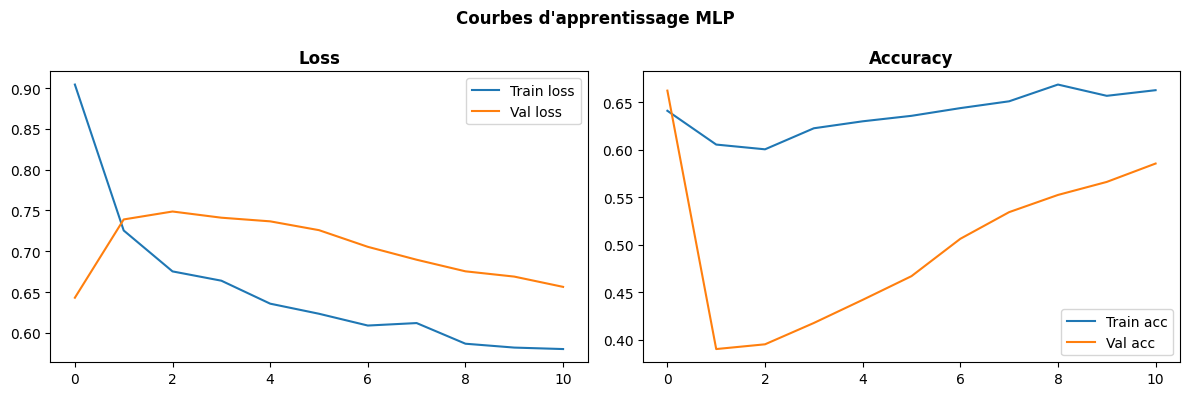


  MLP (Deep Learning)
  Accuracy     : 0.6695
  Precision    : 0.1468
  Recall       : 0.4657
  F1-Score     : 0.2233
  ROC-AUC      : 0.6232

              precision    recall  f1-score   support

   Non-Churn       0.92      0.69      0.79      1796
       Churn       0.15      0.47      0.22       204

    accuracy                           0.67      2000
   macro avg       0.53      0.58      0.51      2000
weighted avg       0.84      0.67      0.73      2000

Modèle sauvegardé : models/mlp_model.keras


In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# Keras ne supporte pas directement class_weight='balanced',
# on calcule donc les poids manuellement avec sklearn.
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
# Conversion en dict {classe: poids} attendu par Keras
class_weight_dict = dict(enumerate(class_weights_array))
print(f"Poids des classes : {class_weight_dict}")

# Architecture choisie (raisonnable pour ~8000 lignes / 38 features) :
#   Input(38) → Dense(128) → BN → Dropout → Dense(64) → BN → Dropout → Dense(32) → Dropout → Dense(1, sigmoid)
# - BatchNormalization stabilise l'entraînement
# - Dropout fait office de régularisation contre l'overfitting
tf.random.set_seed(42)   # reproductibilité côté Keras

mlp = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),                          # 30% de neurones désactivés à chaque batch
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')         # sortie binaire → proba de churn entre 0 et 1
])

mlp.compile(
    optimizer='adam',                       # adam = bon défaut, gère bien les gradients
    loss='binary_crossentropy',             # loss standard pour la classification binaire
    metrics=['accuracy']
)

mlp.summary()

# EarlyStopping : on arrête l'entraînement si la val_loss stagne pendant 10 époques.
# restore_best_weights=True : on revient aux poids de la meilleure époque (pas la dernière).
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = mlp.fit(
    X_train, y_train,
    epochs=100,                  # plafond ; l'EarlyStopping coupera bien avant
    batch_size=256,              # batch assez large → entraînement plus stable
    validation_split=0.2,        # 20% du train pour valider à chaque époque
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

# Courbes d'apprentissage : on regarde si train et val divergent (= overfitting)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss', fontweight='bold')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train acc')
axes[1].plot(history.history['val_accuracy'], label='Val acc')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].legend()

plt.suptitle('Courbes d\'apprentissage MLP', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/mlp_learning_curves.png', dpi=150)
plt.show()

# Petit souci : Keras n'a pas la même API que sklearn (pas de predict_proba).
# Pour réutiliser notre fonction evaluate_model, on enveloppe le modèle
# dans une mini-classe qui imite l'interface sklearn.
y_proba_mlp = mlp.predict(X_test, verbose=0).flatten()
y_pred_mlp  = (y_proba_mlp >= 0.5).astype(int)

class KerasWrapper:
    """Adapte un modèle Keras à l'API sklearn (predict / predict_proba)."""
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        return (self.model.predict(X, verbose=0).flatten() >= 0.5).astype(int)
    def predict_proba(self, X):
        proba = self.model.predict(X, verbose=0).flatten()
        # sklearn attend un array (n, 2) avec [proba_classe_0, proba_classe_1]
        return np.column_stack([1 - proba, proba])

mlp_wrapped = KerasWrapper(mlp)
y_pred_mlp, y_proba_mlp = evaluate_model('MLP (Deep Learning)', mlp_wrapped, X_test, y_test, results)

# Sauvegarde au format Keras natif (.keras)
mlp.save('../models/mlp_model.keras')
print("Modèle sauvegardé : models/mlp_model.keras")


=== Comparaison des modèles ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.8310,0.2781,0.4118,0.3320,0.7908
XGBoost,0.8160,0.2657,0.4559,0.3357,0.7728
Régression Logistique,0.6895,0.1983,0.6716,0.3061,0.7510
MLP (Deep Learning),0.6695,0.1468,0.4657,0.2233,0.6232


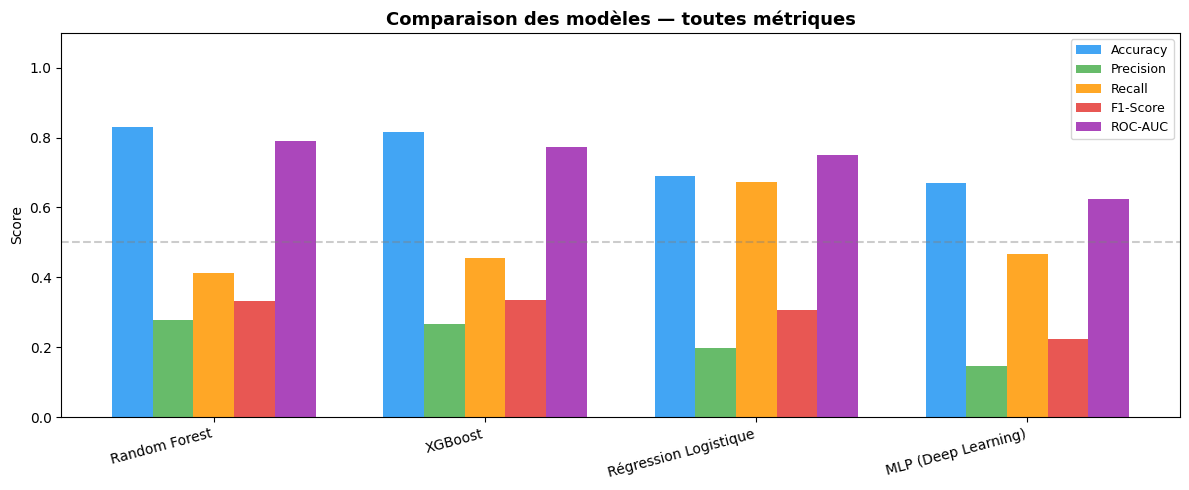

In [20]:
# Construction du tableau, trié par ROC-AUC décroissant
df_results = pd.DataFrame(results).T.round(4)
df_results = df_results.sort_values('ROC-AUC', ascending=False)

print("=== Comparaison des modèles ===")
display(df_results)

# Visualisation en barres groupées : une couleur par métrique
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_results))
width = 0.15   # largeur de chaque barre (5 métriques côte à côte)
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E53935', '#9C27B0']

# On décale chaque métrique de "width" pour qu'elles ne se superposent pas
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax.bar(x + i * width, df_results[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)   # centrage des labels sous les groupes
ax.set_xticklabels(df_results.index, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — toutes métriques', fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
# Ligne de référence à 0.5 = niveau du random sur classification binaire
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='Baseline 0.5')

plt.tight_layout()
plt.savefig('../data/processed/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


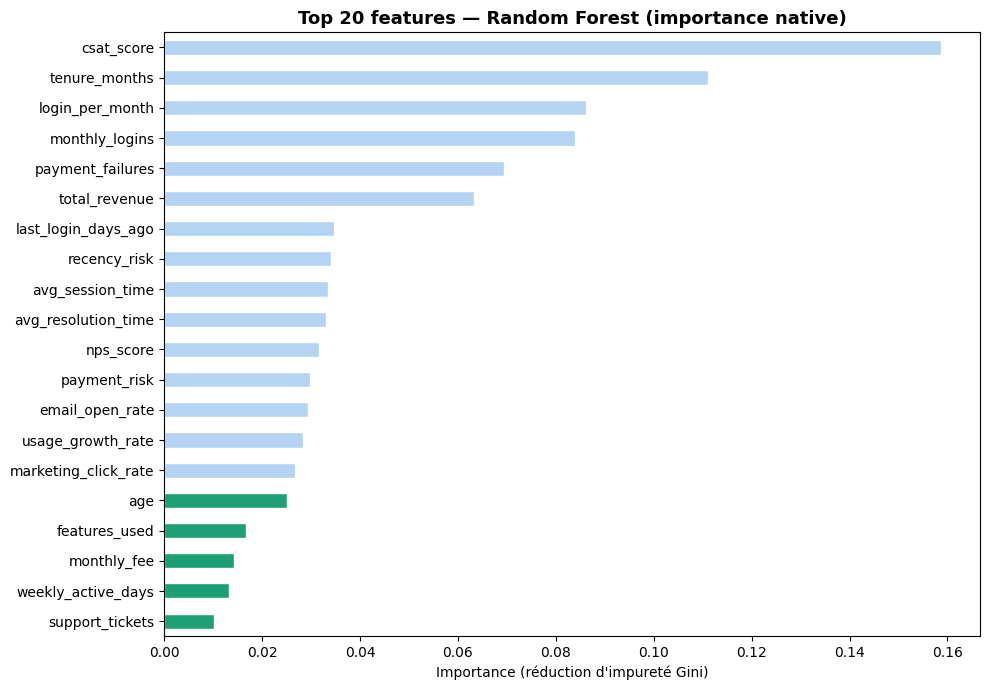

=== Top 10 features les plus importantes ===
csat_score             0.158712
tenure_months          0.110995
login_per_month        0.086071
monthly_logins         0.083932
payment_failures       0.069444
total_revenue          0.063197
last_login_days_ago    0.034683
recency_risk           0.034161
avg_session_time       0.033554
avg_resolution_time    0.033054


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Récupération des importances natives de RF, indexées par nom de feature
feat_importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# On garde le top 20 pour rester lisible
top20 = feat_importances.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
# Petite astuce : colorier en vert le top 5 pour le faire ressortir
colors = ['#1D9E75' if i < 5 else '#B5D4F4' for i in range(len(top20))]
top20.plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.set_title('Top 20 features — Random Forest (importance native)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance (réduction d\'impureté Gini)')
ax.invert_yaxis()   # la feature la plus importante en haut
plt.tight_layout()
plt.savefig('../data/processed/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# On affiche aussi le top 10 en texte pour pouvoir les citer dans le rapport
print("=== Top 10 features les plus importantes ===")
print(feat_importances.head(10).to_string())
# Attention : cette importance dit qui pèse, mais pas dans quel sens.
# Pour ça → SHAP, juste après.


In [22]:
import shap

# TreeExplainer est ultra-rapide sur les modèles à base d'arbres (RF, XGBoost…)
explainer = shap.TreeExplainer(xgb)

# Sur 2000 lignes de test, c'est rapide. Mais comme on va aussi faire
# des plots, on échantillonne à 500 → graphes plus lisibles, calcul plus léger.
X_test_sample = X_test.sample(500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print(f"Shape SHAP values : {shap_values.shape}")
print("SHAP calculé sur 500 exemples du test set")
# shap_values[i, j] = contribution de la feature j à la prédiction du client i


Shape SHAP values : (500, 38)
SHAP calculé sur 500 exemples du test set


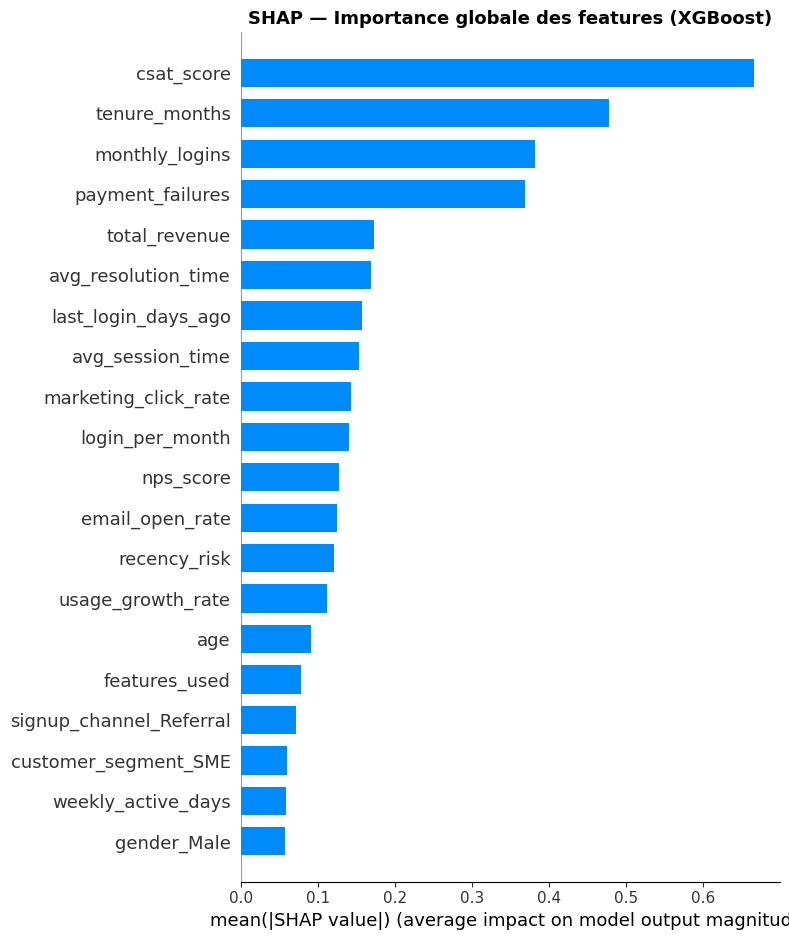

In [23]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type='bar',        # mode "barres" = vue globale, sans direction
    max_display=20,
    show=False              # show=False pour pouvoir personnaliser le titre ensuite
)
plt.title('SHAP — Importance globale des features (XGBoost)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()


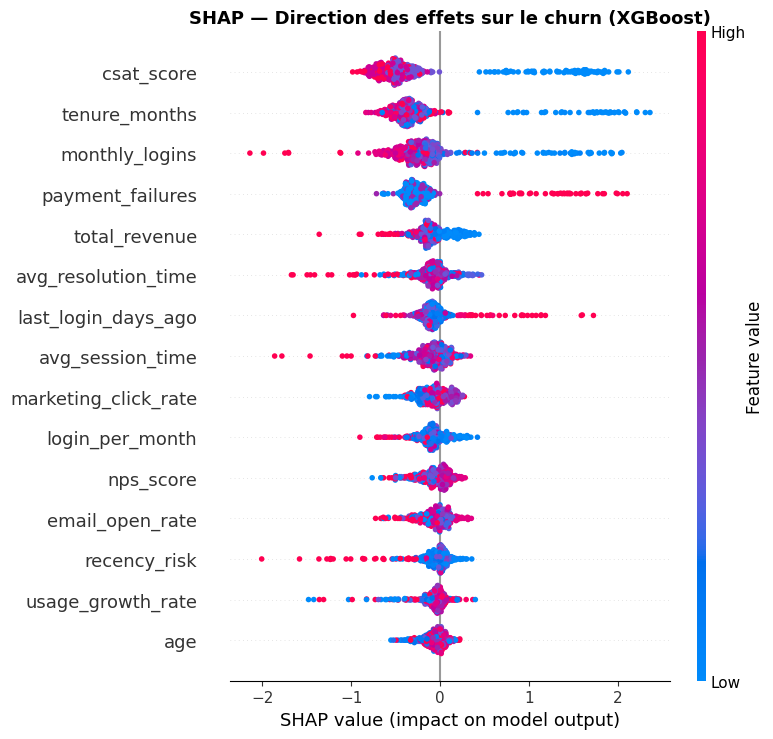

In [24]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type='dot',        # 'dot' = beeswarm (essaim d'abeilles)
    max_display=15,
    show=False
)
plt.title('SHAP — Direction des effets sur le churn (XGBoost)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


Client sélectionné — Probabilité de churn : 9.0%
Vrai label : CHURN = 1


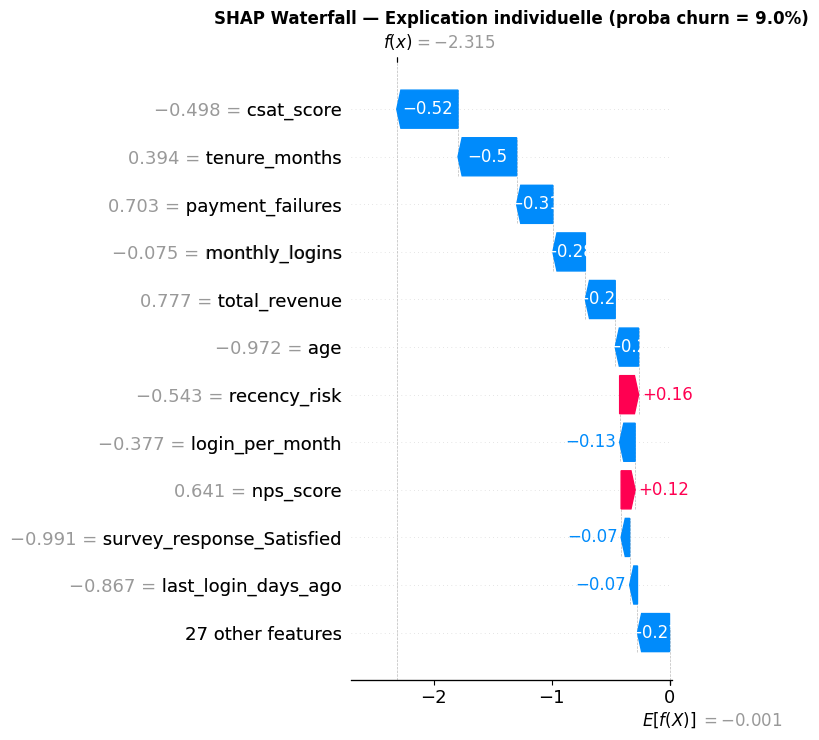

In [25]:
# 1) On cherche les indices des vrais churners dans le test set
churners_idx = y_test[y_test == 1].index.tolist()

# 2) On les croise avec notre échantillon SHAP (500 lignes)
sample_idx_list = X_test_sample.index.tolist()
churner_in_sample = [i for i in sample_idx_list if i in churners_idx]

if churner_in_sample:
    # On prend le premier churner trouvé dans le sample
    local_idx = sample_idx_list.index(churner_in_sample[0])
    client_row = X_test_sample.iloc[[local_idx]]

    # On affiche la proba prédite par XGBoost et le vrai label (sanity check)
    proba_churn = xgb.predict_proba(client_row)[0][1]
    print(f"Client sélectionné — Probabilité de churn : {proba_churn:.1%}")
    print(f"Vrai label : CHURN = {y_test.loc[churner_in_sample[0]]}")

    # 3) Construction de l'objet Explanation attendu par shap.plots.waterfall
    #    base_value : prédiction moyenne du modèle
    #    values     : contribution de chaque feature pour CE client
    #    data       : valeurs des features pour CE client
    explanation = shap.Explanation(
        values=shap_values[local_idx],
        base_values=explainer.expected_value,
        data=client_row.values[0],
        feature_names=X_test_sample.columns.tolist()
    )

    # 4) Waterfall : on part de la prédiction moyenne et on ajoute/retire
    #    les contributions de chaque feature jusqu'à arriver à la proba finale.
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f'SHAP Waterfall — Explication individuelle (proba churn = {proba_churn:.1%})',
              fontweight='bold')
    plt.tight_layout()
    plt.savefig('../data/processed/shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    # Cas improbable : aucun churner dans les 500 lignes du sample
    print("Aucun churner dans l'échantillon — relance avec random_state différent")


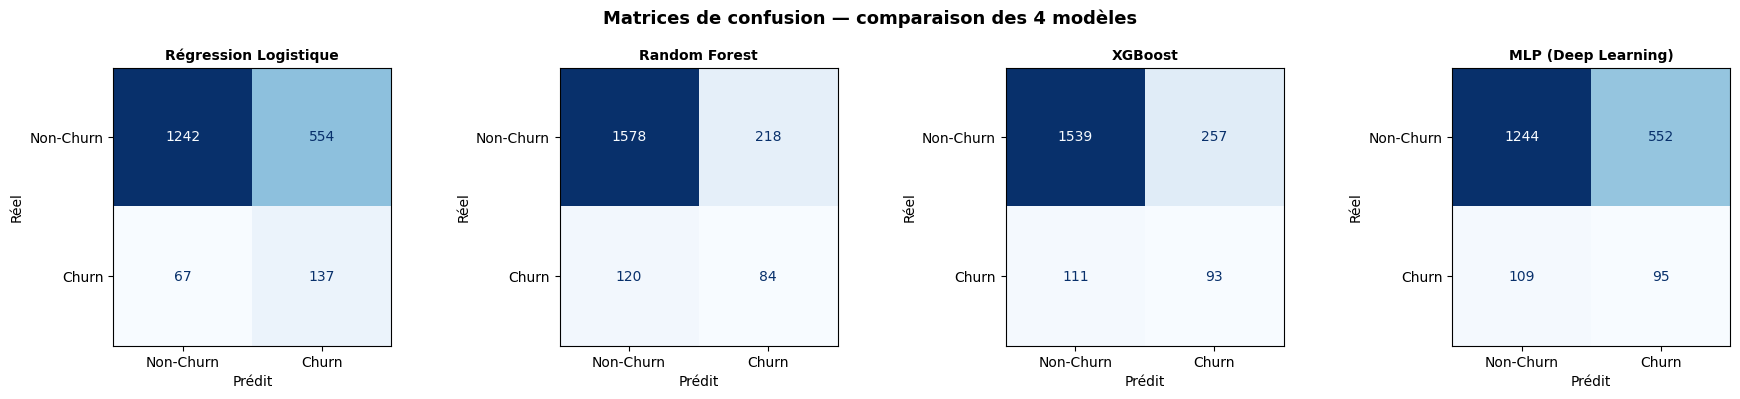

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

# On regroupe les 4 modèles dans un dict pour boucler dessus proprement
models_dict = {
    'Régression Logistique' : (lr,           '#2196F3'),
    'Random Forest'         : (rf,           '#4CAF50'),
    'XGBoost'               : (xgb,          '#FF9800'),
    'MLP (Deep Learning)'   : (mlp_wrapped,  '#9C27B0')
}

# 4 sous-graphes côte à côte → comparaison visuelle directe
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, (model, color)) in zip(axes, models_dict.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Non-Churn', 'Churn']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de confusion — comparaison des 4 modèles',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

